<a href="https://colab.research.google.com/github/rasa-coder/AI_First_Project/blob/main/Copy_of_Transformer_vs_ML_Cyberbullying_G04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Toxic Comment Multi-Label Classification

**Dataset:** Heliosoph/Jigsaw-Toxic-Comments

**6 independent binary label columns:** toxic, severe_toxic, obscene, threat, insult, identity_hate

This is a multi-label task — a comment can carry any combination of the 6 labels simultaneously.
BCEWithLogitsLoss (one sigmoid per label) replaces the single binary cross-entropy used previously.

In [ ]:

import subprocess
subprocess.run(['pip', 'install', 'transformers', 'datasets', 'scikit-learn', '-q'])


CompletedProcess(args=['pip', 'install', 'transformers', 'datasets', 'scikit-learn', '-q'], returncode=0)

In [ ]:

import sys

try:
    import torchvision.io as _tvio
except ImportError:
    pass


import types
import importlib


try:
    import torchvision.io
    if not hasattr(torchvision.io, 'VideoReader'):
        class _DummyVideoReader:
            def __init__(self, *a, **kw):
                raise RuntimeError("VideoReader is not available in this torchvision build.")
        torchvision.io.VideoReader = _DummyVideoReader
        print("✅ Patched: torchvision.io.VideoReader placeholder injected.")
except Exception as e:
    print(f"torchvision patch skipped: {e}")

✅ Patched: torchvision.io.VideoReader placeholder injected.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from datasets import load_dataset

raw = load_dataset(
    'Heliosoph/Jigsaw-Toxic-Comments',
    data_files='train.csv.gz',
    split='train'
)
print(raw)
print(raw[0])
print('Columns:', raw.column_names)


README.md:   0%|          | 0.00/8.74k [00:00<?, ?B/s]

train.csv.gz: reconstructing file:   0%|          |  0.00B / 26.7MB            

train.csv.gz: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
    num_rows: 159571
})
{'id': '0000997932d777bf', 'comment_text': "Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27", 'toxic': 0, 'severe_toxic': 0, 'obscene': 0, 'threat': 0, 'insult': 0, 'identity_hate': 0}
Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [ ]:
import pandas as pd

df = raw.to_pandas()
LABEL_COLS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

print(f'Total samples: {len(df)}')
print('Label counts (positive examples per class):')
print(df[LABEL_COLS].sum())
print('Label prevalence (%):')
print((df[LABEL_COLS].mean() * 100).round(2))
print('Clean (no label):', (df[LABEL_COLS].sum(axis=1) == 0).sum())
print('Toxic (>=1 label):', (df[LABEL_COLS].sum(axis=1) > 0).sum())


Total samples: 159571
Label counts (positive examples per class):
toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64
Label prevalence (%):
toxic            9.58
severe_toxic     1.00
obscene          5.29
threat           0.30
insult           4.94
identity_hate    0.88
dtype: float64
Clean (no label): 143346
Toxic (>=1 label): 16225


In [ ]:

TRANSFORMER_MODELS = {
    'BERT': 'bert-base-uncased',
    'DistilBERT': 'distilbert-base-uncased'
}

CLASSICAL_MODELS = [
    'RandomForest',
    'XGBoost'
]

ALL_MODELS = list(TRANSFORMER_MODELS.keys()) + CLASSICAL_MODELS

LABEL_COLS = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

NUM_LABELS = len(LABEL_COLS)
THRESHOLD = 0.5


all_results = {}
test_results = {}
all_probs = {}
all_preds = {}
all_labels = {}

print("Transformer Models:", list(TRANSFORMER_MODELS.keys()))
print("Classical Models:", CLASSICAL_MODELS)
print("All Models:", ALL_MODELS)

Transformer Models: ['BERT', 'DistilBERT']
Classical Models: ['RandomForest', 'XGBoost']
All Models: ['BERT', 'DistilBERT', 'RandomForest', 'XGBoost']


In [ ]:

import torch
bf16_supported = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
print(f"bf16 supported: {bf16_supported}")

bf16 supported: True


In [ ]:
import numpy as np
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    accuracy_score
)

THRESHOLD = 0.5

def make_compute_metrics(threshold=0.5):

    def compute_metrics(eval_pred):

        logits, labels = eval_pred

        probs = 1/(1+np.exp(-logits))
        preds = (probs >= threshold).astype(int)

        labels = labels.astype(int)

        f1_micro = f1_score(
            labels,
            preds,
            average='micro',
            zero_division=0
        )

        f1_macro = f1_score(
            labels,
            preds,
            average='macro',
            zero_division=0
        )

        try:
            roc_auc = roc_auc_score(
                labels,
                probs,
                average='macro'
            )
        except:
            roc_auc = float('nan')

        acc = accuracy_score(labels, preds)

        return {
            "f1_micro": f1_micro,
            "f1_macro": f1_macro,
            "roc_auc": roc_auc,
            "accuracy": acc
        }

    return compute_metrics

In [ ]:
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split

LABEL_COLS = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

df = raw.to_pandas()[['comment_text'] + LABEL_COLS]

df['labels'] = df[LABEL_COLS].astype(float).values.tolist()


train_val_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.125,
    random_state=42
)

dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df.reset_index(drop=True)),
    'validation': Dataset.from_pandas(val_df.reset_index(drop=True)),
    'test': Dataset.from_pandas(test_df.reset_index(drop=True))
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'labels'],
        num_rows: 111699
    })
    validation: Dataset({
        features: ['comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'labels'],
        num_rows: 15957
    })
    test: Dataset({
        features: ['comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'labels'],
        num_rows: 31915
    })
})


In [ ]:
model_name = "BERT"
model_checkpoint = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize(batch):

    tokens = tokenizer(
        batch['comment_text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

    tokens['labels'] = [
        [float(v) for v in row]
        for row in batch['labels']
    ]

    return tokens

tokenized = dataset.map(
    tokenize,
    batched=True,
    remove_columns=dataset['train'].column_names
)

tokenized.set_format('torch')

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=NUM_LABELS,
    problem_type='multi_label_classification',
    ignore_mismatched_sizes=True
)

training_args = TrainingArguments(
    output_dir='./toxic-multilabel-bert',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_micro',
    fp16=True,
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    compute_metrics=make_compute_metrics()
)

trainer.train()

val_metrics = trainer.evaluate()

all_results[model_name] = val_metrics

test_output = trainer.predict(tokenized['test'])

logits = test_output.predictions
labels = test_output.label_ids.astype(int)

probs = 1/(1+np.exp(-logits))
preds = (probs >= THRESHOLD).astype(int)

all_probs[model_name] = probs
all_preds[model_name] = preds
all_labels[model_name] = labels

test_results[model_name] = {
    'accuracy': accuracy_score(labels, preds),
    'roc_auc': roc_auc_score(labels, probs, average='macro')
}

print("BERT Finished")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/111699 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training Loss,Validation Loss,Epoch,F1 Micro,F1 Macro,Roc Auc,Accuracy
0.040800,0.039813,3,0.793759,0.670567,0.989219,0.926929


BERT Finished


In [ ]:
model_name = "DistilBERT"
model_checkpoint = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize(batch):

    tokens = tokenizer(
        batch['comment_text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

    tokens['labels'] = [
        [float(v) for v in row]
        for row in batch['labels']
    ]

    return tokens

tokenized = dataset.map(
    tokenize,
    batched=True,
    remove_columns=dataset['train'].column_names
)

tokenized.set_format('torch')

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=NUM_LABELS,
    problem_type='multi_label_classification',
    ignore_mismatched_sizes=True
)

training_args = TrainingArguments(
    output_dir='./toxic-multilabel-distilbert',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_micro',
    fp16=True,
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    compute_metrics=make_compute_metrics()
)

trainer.train()

val_metrics = trainer.evaluate()
all_results[model_name] = val_metrics

test_output = trainer.predict(tokenized['test'])

logits = test_output.predictions
labels = test_output.label_ids.astype(int)

probs = 1/(1+np.exp(-logits))
preds = (probs >= THRESHOLD).astype(int)

all_probs[model_name] = probs
all_preds[model_name] = preds
all_labels[model_name] = labels

test_results[model_name] = {
    'accuracy': accuracy_score(labels, preds),
    'roc_auc': roc_auc_score(labels, probs, average='macro')
}

print("DistilBERT Finished")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/111699 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,F1 Micro,F1 Macro,Roc Auc,Accuracy
0.045260,0.044369,3,0.793921,0.669418,0.988574,0.925989


DistilBERT Finished


In [ ]:
!pip install xgboost -q

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(train_df['comment_text'])
X_val_tfidf   = vectorizer.transform(val_df['comment_text'])
X_test_tfidf  = vectorizer.transform(test_df['comment_text'])

y_train = train_df[LABEL_COLS].values
y_val   = val_df[LABEL_COLS].values
y_test  = test_df[LABEL_COLS].values

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(111699, 5000)
(31915, 5000)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

print("="*60)
print("Training Random Forest")
print("="*60)

rf_model = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )
)

rf_model.fit(X_train_tfidf, y_train)

rf_preds = rf_model.predict(X_test_tfidf)

rf_probs = np.column_stack([
    est.predict_proba(X_test_tfidf)[:,1]
    for est in rf_model.estimators_
])

all_preds["RandomForest"] = rf_preds
all_probs["RandomForest"] = rf_probs
all_labels["RandomForest"] = y_test

rf_acc = accuracy_score(y_test, rf_preds)

try:
    rf_auc = roc_auc_score(
        y_test,
        rf_probs,
        average="macro"
    )
except:
    rf_auc = float("nan")

test_results["RandomForest"] = {
    "accuracy": rf_acc,
    "roc_auc": rf_auc
}

all_results["RandomForest"] = {
    "eval_accuracy": rf_acc,
    "eval_roc_auc": rf_auc
}

print("Random Forest Accuracy:", rf_acc)
print("Random Forest AUC:", rf_auc)

Training Random Forest
Random Forest Accuracy: 0.899545668181106
Random Forest AUC: 0.9617338543395163


In [ ]:
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

print("="*60)
print("Training XGBoost")
print("="*60)

xgb_model = MultiOutputClassifier(
    XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )
)

xgb_model.fit(X_train_tfidf, y_train)

xgb_preds = xgb_model.predict(X_test_tfidf)

xgb_probs = np.column_stack([
    est.predict_proba(X_test_tfidf)[:,1]
    for est in xgb_model.estimators_
])

all_preds["XGBoost"] = xgb_preds
all_probs["XGBoost"] = xgb_probs
all_labels["XGBoost"] = y_test

xgb_acc = accuracy_score(y_test, xgb_preds)

try:
    xgb_auc = roc_auc_score(
        y_test,
        xgb_probs,
        average="macro"
    )
except:
    xgb_auc = float("nan")

test_results["XGBoost"] = {
    "accuracy": xgb_acc,
    "roc_auc": xgb_auc
}

all_results["XGBoost"] = {
    "eval_accuracy": xgb_acc,
    "eval_roc_auc": xgb_auc
}

print("XGBoost Accuracy:", xgb_acc)
print("XGBoost AUC:", xgb_auc)

Training XGBoost
XGBoost Accuracy: 0.918972270092433
XGBoost AUC: 0.9638362748259047


In [ ]:

import pickle

with open("/content/drive/MyDrive/project_results.pkl", "wb") as f:
    pickle.dump(
        {
            "all_results": all_results,
            "test_results": test_results,
            "all_probs": all_probs,
            "all_preds": all_preds,
            "all_labels": all_labels
        },
        f
    )

print(" Results saved to Google Drive")

✅ Results saved to Google Drive


In [ ]:

import pickle

with open("/content/drive/MyDrive/project_results.pkl", "rb") as f:
    data = pickle.load(f)

all_results = data["all_results"]
test_results = data["test_results"]
all_probs = data["all_probs"]
all_preds = data["all_preds"]
all_labels = data["all_labels"]

print(" Results loaded from Google Drive")

✅ Results loaded from Google Drive


In [ ]:

import pandas as pd

MODELS = [
    "BERT",
    "DistilBERT",
    "RandomForest",
    "XGBoost"
]

rows = []

for m in MODELS:

    if m not in test_results:
        continue

    row = {"Model": m}

    row["Val F1 (micro)"] = all_results.get(m, {}).get(
    "eval_f1_micro",
    "-"
    )

    row["Val F1 (macro)"] = all_results.get(m, {}).get(
    "eval_f1_macro",
    "-"
    )

    row["Val AUC"] = all_results.get(m, {}).get(
        "eval_roc_auc",
        float("nan")
    )

    row["Test Accuracy"] = test_results[m]["accuracy"]

    row["Test AUC"] = test_results[m]["roc_auc"]

    rows.append(row)

summary_df = pd.DataFrame(rows)

summary_df = summary_df.sort_values(
    by="Test AUC",
    ascending=False
)

summary_df = summary_df.set_index("Model")

print(summary_df.round(4).to_string())

             Val F1 (micro) Val F1 (macro)  Val AUC  Test Accuracy  Test AUC
Model                                                                       
DistilBERT         0.793921       0.669418   0.9886         0.9274    0.9898
BERT               0.793759       0.670567   0.9892         0.9281    0.9879
XGBoost                   -              -   0.9638         0.9190    0.9638
RandomForest              -              -   0.9617         0.8995    0.9617


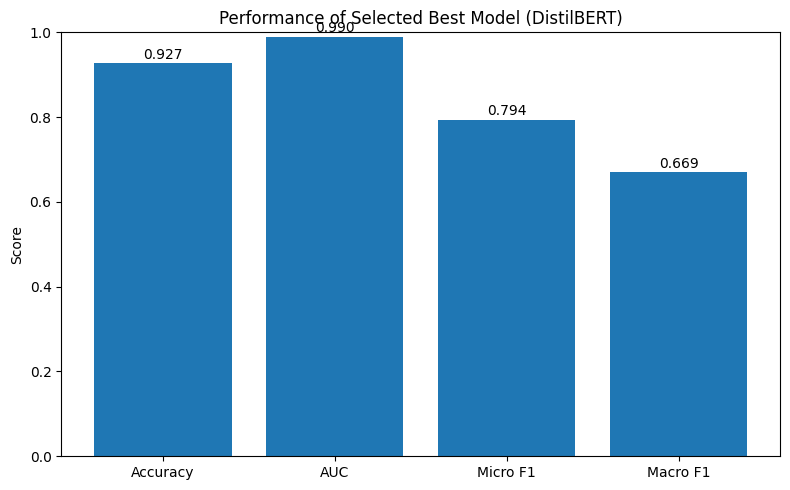

Best Model: DistilBERT


In [ ]:

import matplotlib.pyplot as plt

best_model = max(test_results, key=lambda m: test_results[m]['roc_auc'])

metrics = {
    "Accuracy": test_results[best_model]["accuracy"],
    "AUC": test_results[best_model]["roc_auc"],
    "Micro F1": all_results[best_model]["eval_f1_micro"],
    "Macro F1": all_results[best_model]["eval_f1_macro"]
}

plt.figure(figsize=(8,5))

plt.bar(metrics.keys(), metrics.values())

plt.ylim(0,1)

plt.title(f"Performance of Selected Best Model ({best_model})")
plt.ylabel("Score")

for i, v in enumerate(metrics.values()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.tight_layout()

plt.savefig("best_model_performance.png", dpi=150)

plt.show()

print(f"Best Model: {best_model}")

In [ ]:

from sklearn.metrics import classification_report

LABEL_COLS = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

print("Classification Report — DistilBERT\n")

print(
    classification_report(
        all_labels["DistilBERT"],
        all_preds["DistilBERT"],
        target_names=LABEL_COLS,
        zero_division=0
    )
)

Classification Report — DistilBERT

               precision    recall  f1-score   support

        toxic       0.84      0.82      0.83      3056
 severe_toxic       0.56      0.29      0.38       321
      obscene       0.84      0.83      0.84      1715
       threat       0.55      0.54      0.54        74
       insult       0.79      0.75      0.77      1614
identity_hate       0.68      0.53      0.60       294

    micro avg       0.81      0.77      0.79      7074
    macro avg       0.71      0.63      0.66      7074
 weighted avg       0.80      0.77      0.79      7074
  samples avg       0.07      0.07      0.07      7074



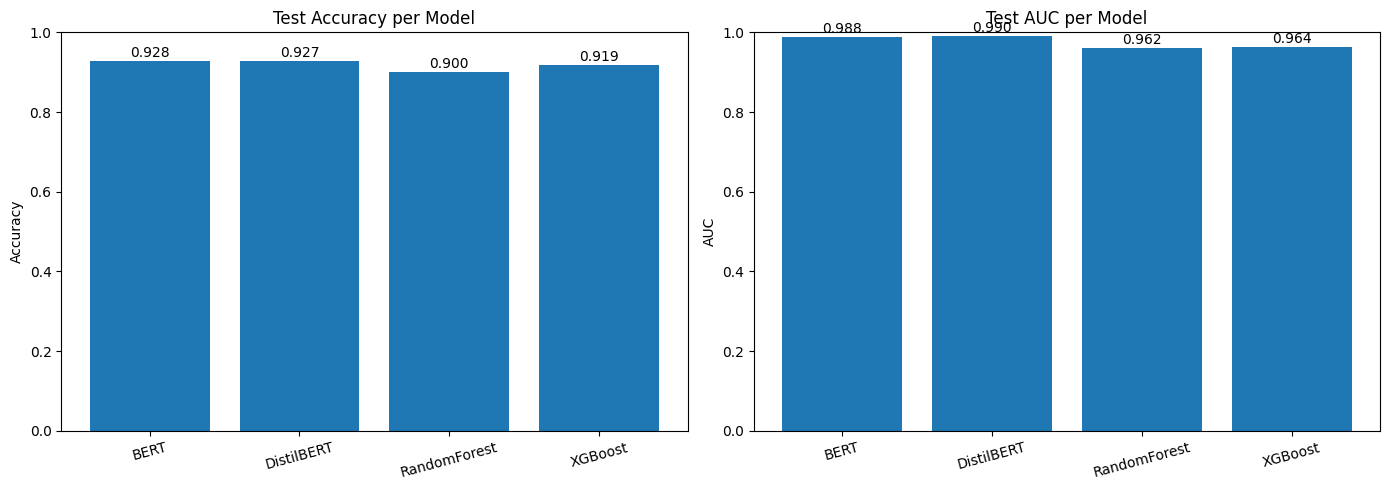

In [ ]:

import matplotlib.pyplot as plt

models = [
    "BERT",
    "DistilBERT",
    "RandomForest",
    "XGBoost"
]

accs = [test_results[m]["accuracy"] for m in models]
aucs = [test_results[m]["roc_auc"] for m in models]

x = range(len(models))

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].bar(x, accs)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(models, rotation=15)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Test Accuracy per Model")
axes[0].set_ylim(0,1)

for i, v in enumerate(accs):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center")

axes[1].bar(x, aucs)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(models, rotation=15)
axes[1].set_ylabel("AUC")
axes[1].set_title("Test AUC per Model")
axes[1].set_ylim(0,1)

for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.tight_layout()

plt.savefig("model_comparison.png", dpi=150)

plt.show()

In [ ]:

from sklearn.metrics import classification_report

print("Classification Report — DistilBERT\n")

print(
    classification_report(
        all_labels["DistilBERT"],
        all_preds["DistilBERT"],
        target_names=LABEL_COLS,
        zero_division=0
    )
)

Classification Report — DistilBERT

               precision    recall  f1-score   support

        toxic       0.84      0.82      0.83      3056
 severe_toxic       0.56      0.29      0.38       321
      obscene       0.84      0.83      0.84      1715
       threat       0.55      0.54      0.54        74
       insult       0.79      0.75      0.77      1614
identity_hate       0.68      0.53      0.60       294

    micro avg       0.81      0.77      0.79      7074
    macro avg       0.71      0.63      0.66      7074
 weighted avg       0.80      0.77      0.79      7074
  samples avg       0.07      0.07      0.07      7074



In [ ]:

import numpy as np
from sklearn.metrics import accuracy_score

LABEL_COLS = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

probs = all_probs["DistilBERT"]
labels = all_labels["DistilBERT"]

print("Original threshold: 0.50")

original_preds = (probs >= 0.50).astype(int)

original_accuracy = accuracy_score(
    labels,
    original_preds
)

print(f"Original Accuracy: {original_accuracy:.4f}")

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

results = []

for threshold in thresholds:

    preds = (probs >= threshold).astype(int)

    accuracy = accuracy_score(
        labels,
        preds
    )

    results.append(
        (threshold, accuracy)
    )


print("\nThreshold Results")
print("-" * 35)

for threshold, accuracy in results:

    print(
        f"Threshold = {threshold:.2f} "
        f"| Accuracy = {accuracy:.4f}"
    )


best_threshold, best_accuracy = max(
    results,
    key=lambda x: x[1]
)

print("\n" + "=" * 40)
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best Accuracy:  {best_accuracy:.4f}")
print(f"Best Accuracy:  {best_accuracy * 100:.2f}%")
print("=" * 40)

Original threshold: 0.50
Original Accuracy: 0.9274

Threshold Results
-----------------------------------
Threshold = 0.10 | Accuracy = 0.9071
Threshold = 0.15 | Accuracy = 0.9131
Threshold = 0.20 | Accuracy = 0.9169
Threshold = 0.25 | Accuracy = 0.9204
Threshold = 0.30 | Accuracy = 0.9225
Threshold = 0.35 | Accuracy = 0.9244
Threshold = 0.40 | Accuracy = 0.9266
Threshold = 0.45 | Accuracy = 0.9271
Threshold = 0.50 | Accuracy = 0.9274
Threshold = 0.55 | Accuracy = 0.9277
Threshold = 0.60 | Accuracy = 0.9275
Threshold = 0.65 | Accuracy = 0.9278
Threshold = 0.70 | Accuracy = 0.9272
Threshold = 0.75 | Accuracy = 0.9266
Threshold = 0.80 | Accuracy = 0.9263
Threshold = 0.85 | Accuracy = 0.9253
Threshold = 0.90 | Accuracy = 0.9210

Best Threshold: 0.65
Best Accuracy:  0.9278
Best Accuracy:  92.78%


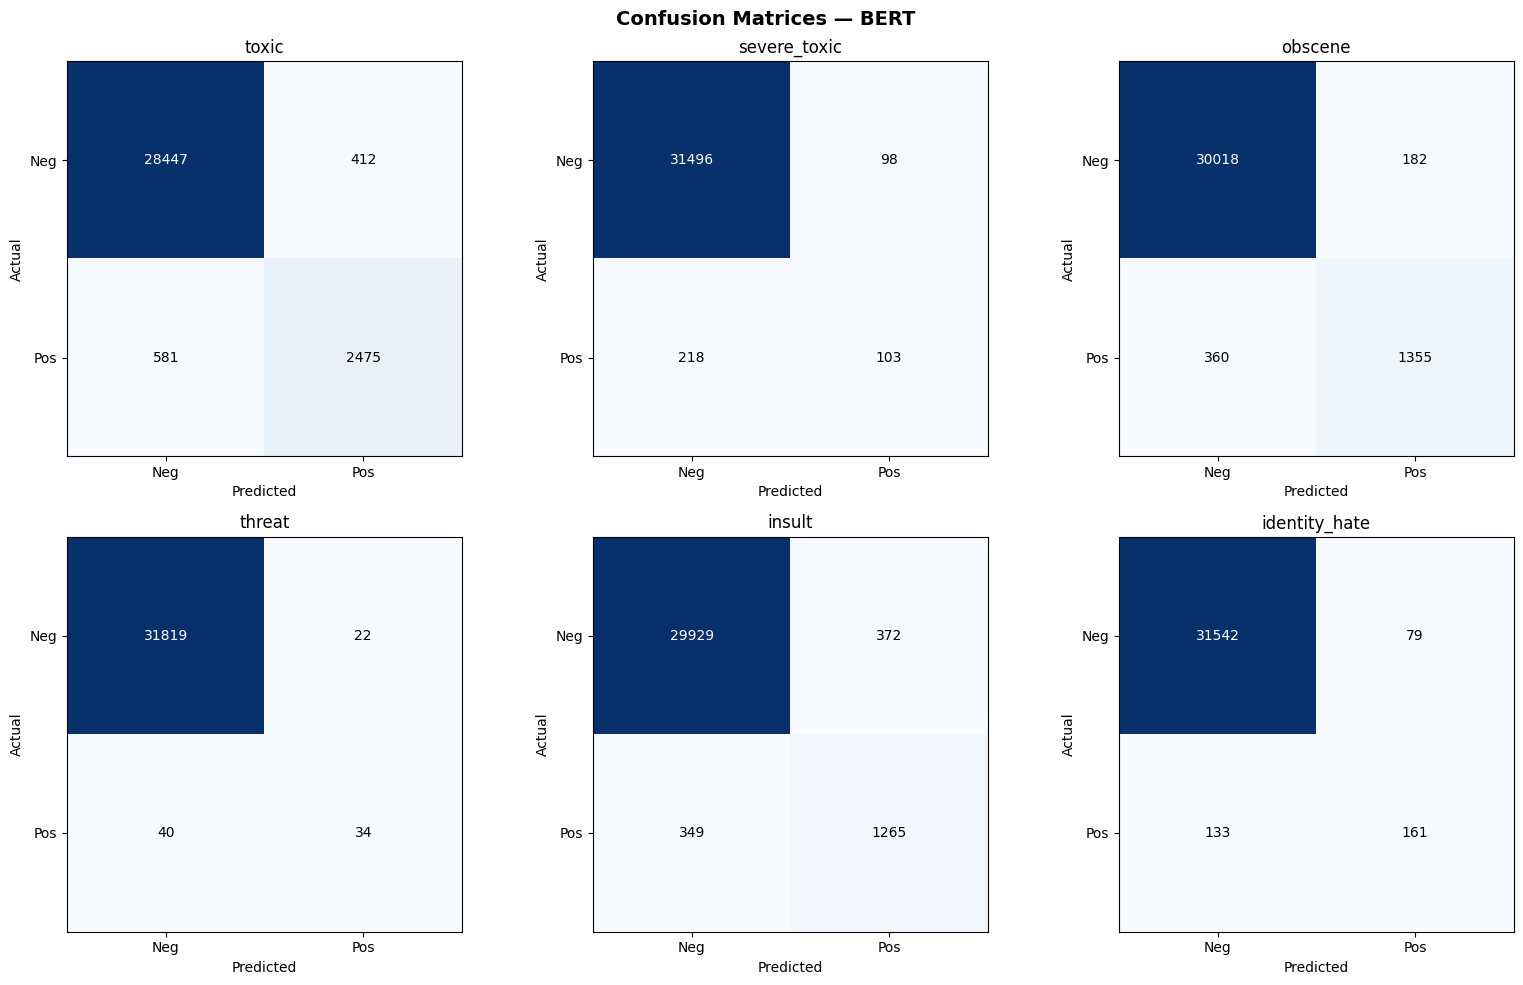

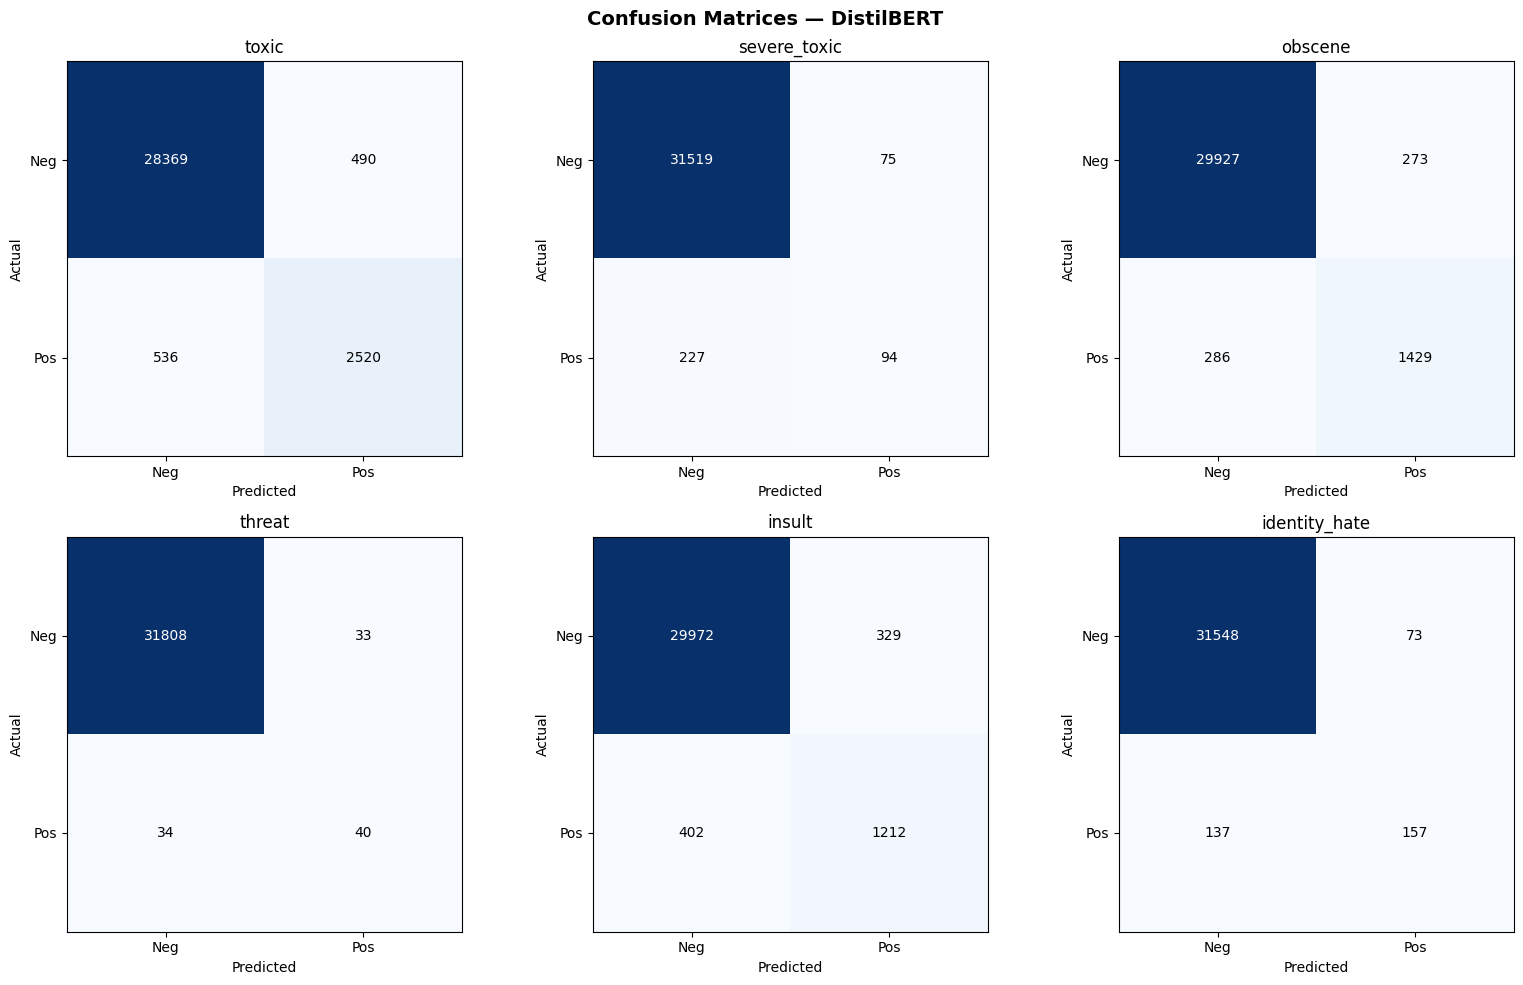

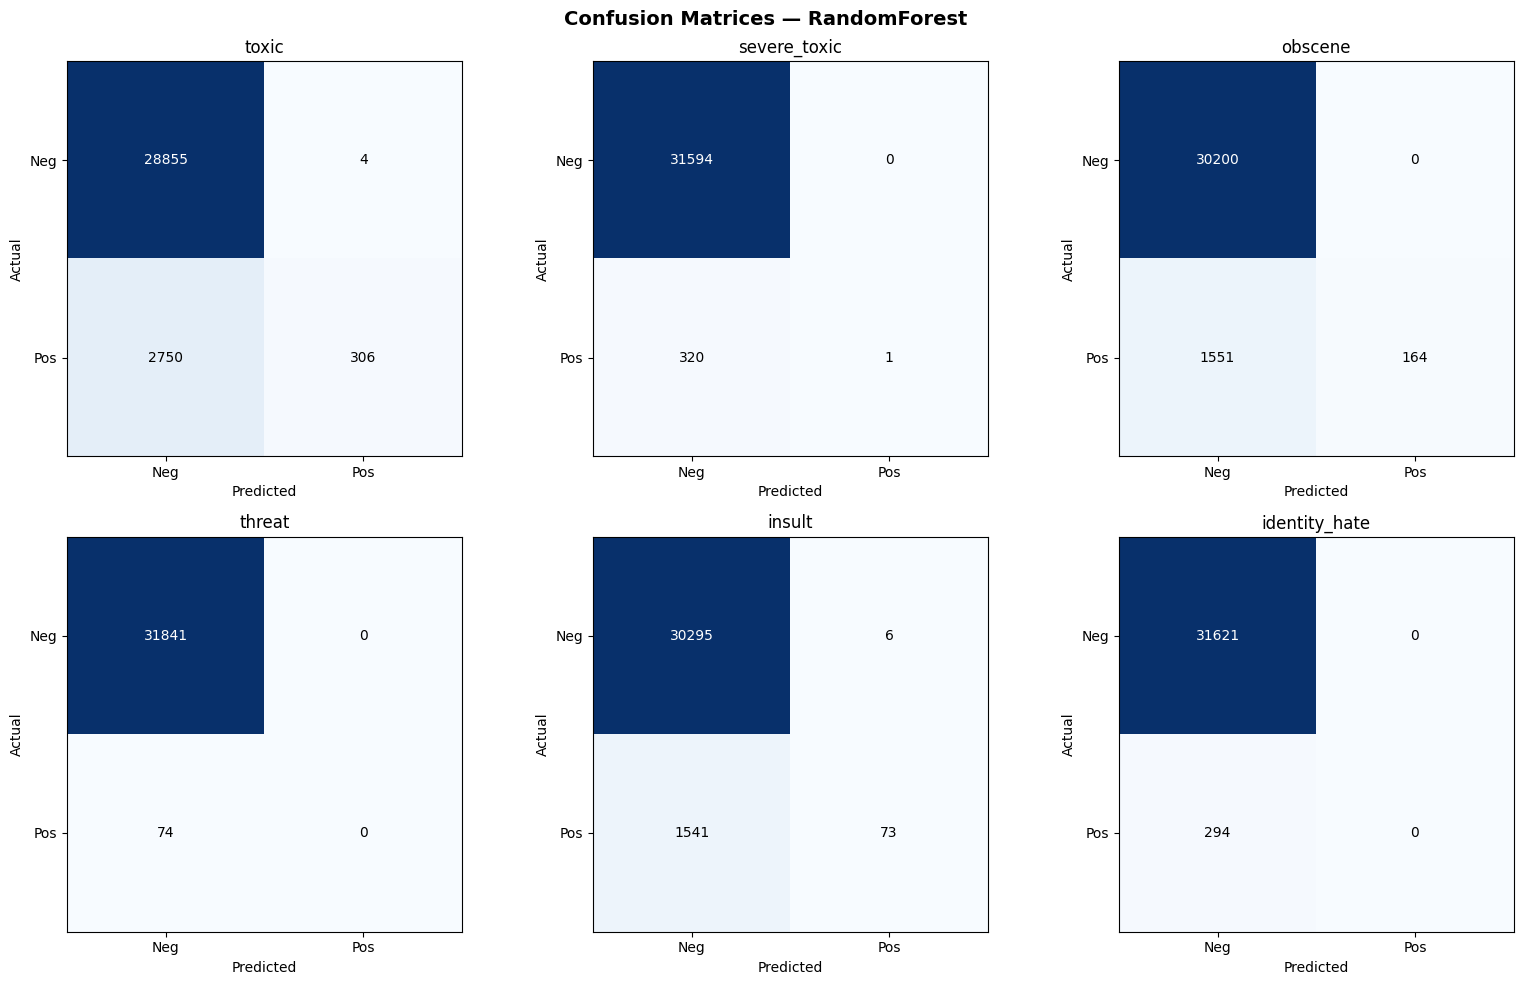

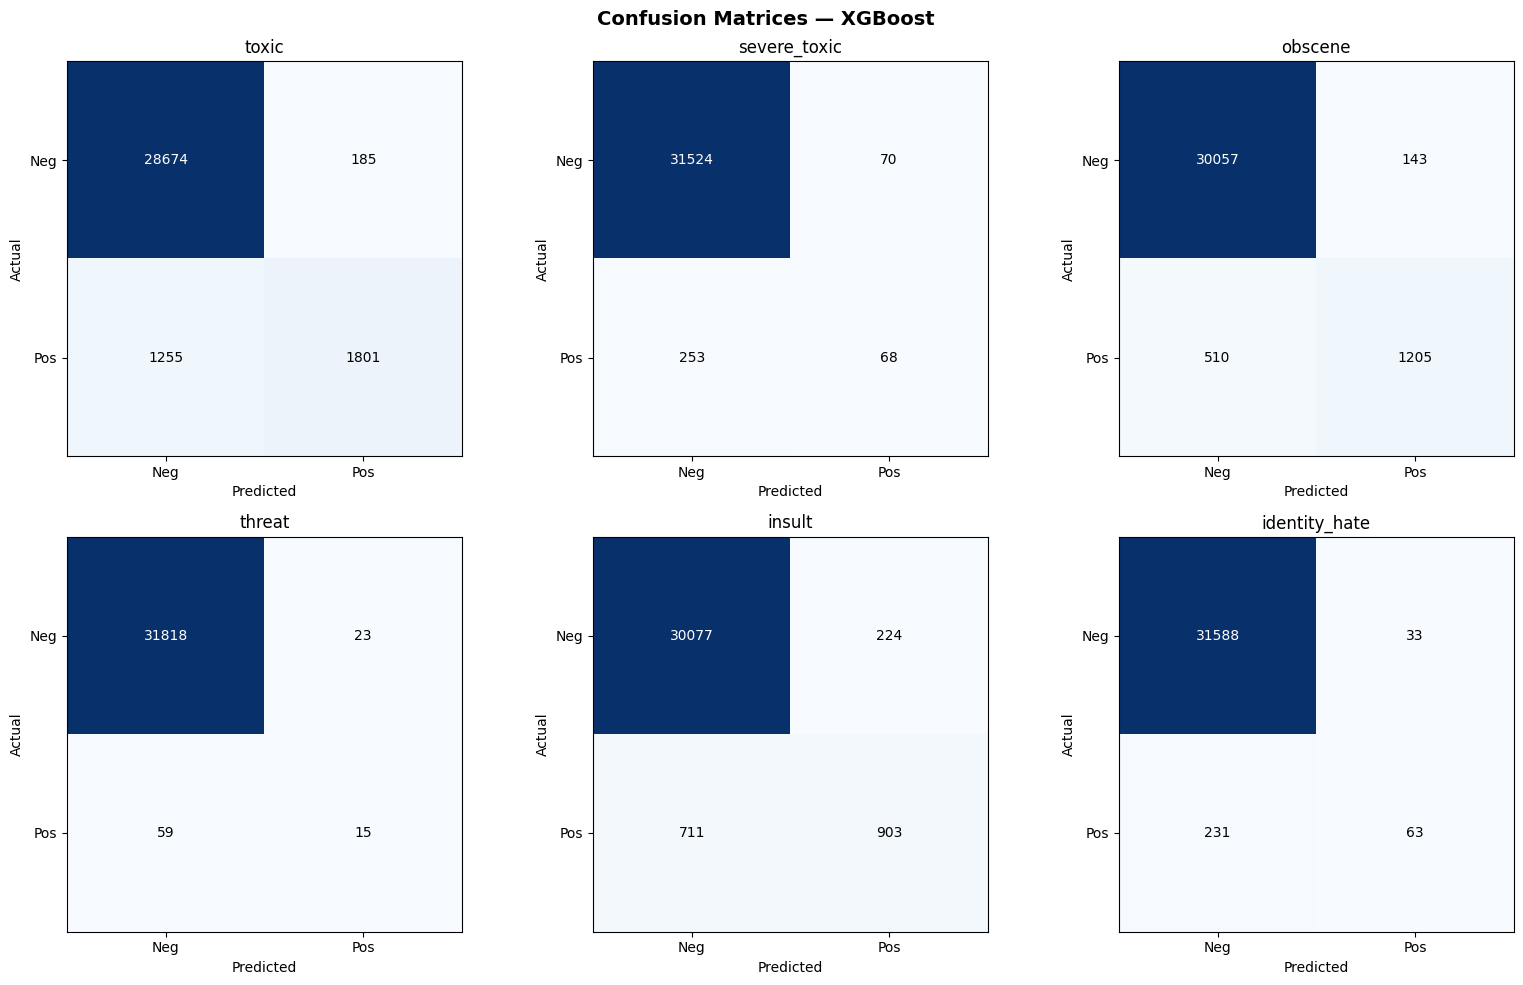

In [ ]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

LABEL_COLS = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

for model_name in [
    "BERT",
    "DistilBERT",
    "RandomForest",
    "XGBoost"
]:

    preds = all_preds[model_name]
    labels = all_labels[model_name]

    fig, axes = plt.subplots(2, 3, figsize=(16,10))
    fig.suptitle(
        f'Confusion Matrices — {model_name}',
        fontsize=14,
        fontweight='bold'
    )

    for idx, label in enumerate(LABEL_COLS):

        ax = axes[idx // 3][idx % 3]

        cm = confusion_matrix(
            labels[:, idx],
            preds[:, idx]
        )

        ax.imshow(cm, cmap='Blues')

        ax.set_title(label)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

        ax.set_xticks([0,1])
        ax.set_yticks([0,1])

        ax.set_xticklabels(['Neg','Pos'])
        ax.set_yticklabels(['Neg','Pos'])

        for i in range(2):
            for j in range(2):
                ax.text(
                    j,
                    i,
                    str(cm[i,j]),
                    ha='center',
                    va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black'
                )

    plt.tight_layout()

    plt.savefig(
        f'confusion_{model_name.lower()}.png',
        dpi=120
    )

    plt.show()

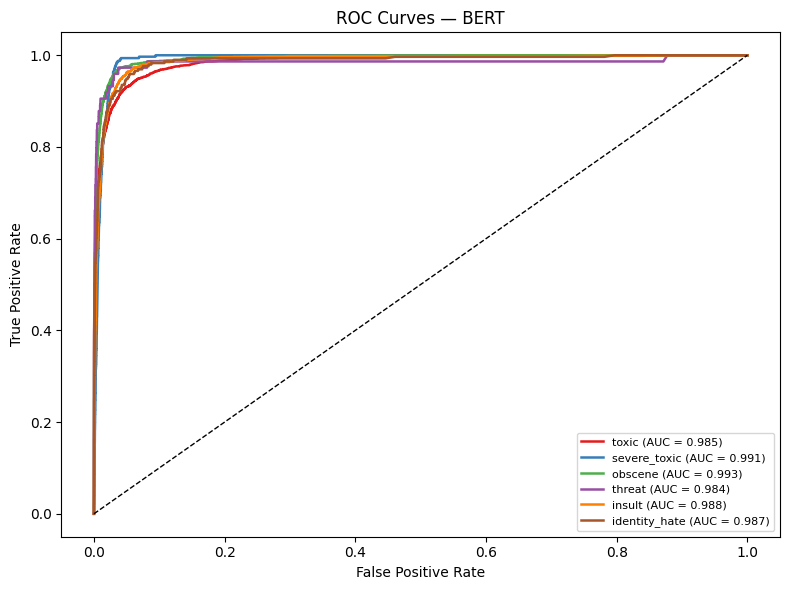

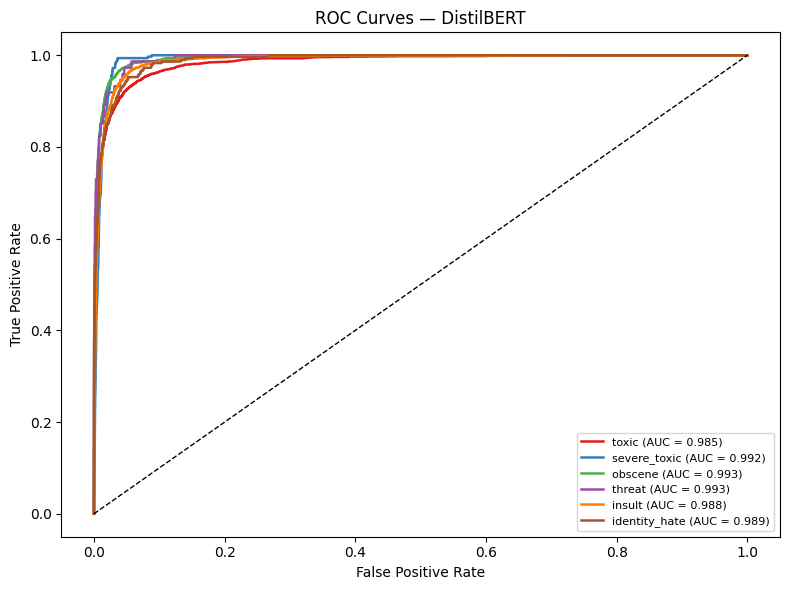

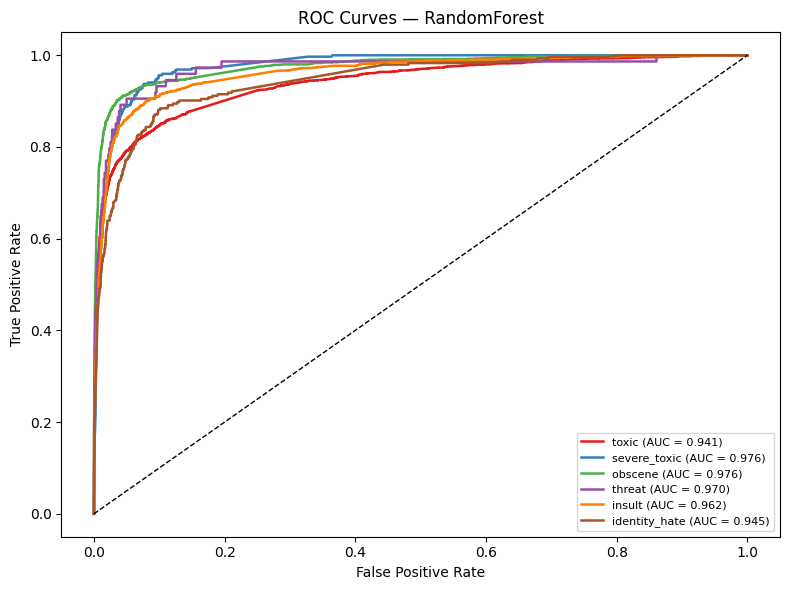

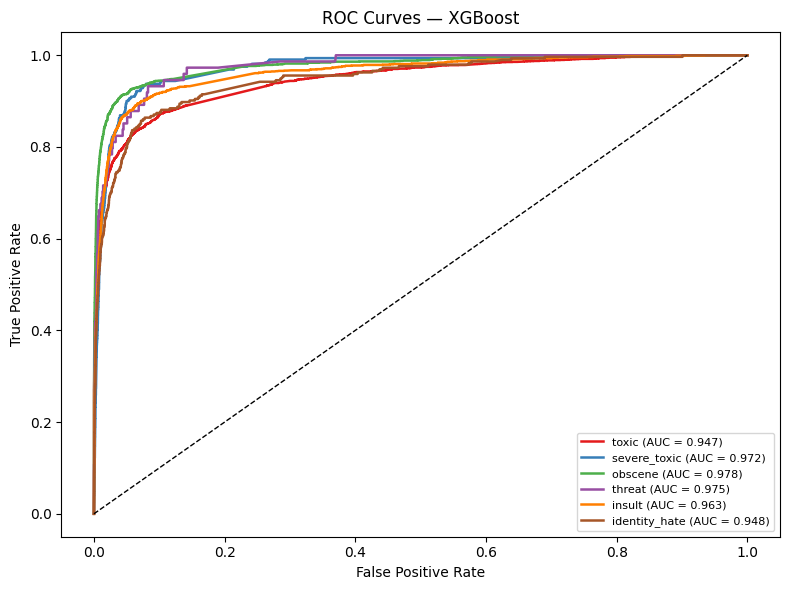

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

LABEL_COLS = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

colors = [
    '#e41a1c',
    '#377eb8',
    '#4daf4a',
    '#984ea3',
    '#ff7f00',
    '#a65628'
]

for model_name in [
    "BERT",
    "DistilBERT",
    "RandomForest",
    "XGBoost"
]:

    probs = all_probs[model_name]
    labels = all_labels[model_name]

    plt.figure(figsize=(8,6))

    plotted = False

    for idx, label in enumerate(LABEL_COLS):

        y_true = labels[:, idx]
        y_prob = probs[:, idx]

        if len(np.unique(y_true)) < 2:
            continue

        if np.isnan(y_prob).any():
            continue

        fpr, tpr, _ = roc_curve(y_true, y_prob)

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            color=colors[idx],
            lw=1.8,
            label=f'{label} (AUC = {roc_auc:.3f})'
        )

        plotted = True

    if plotted:

        plt.plot([0,1], [0,1], 'k--', lw=1)

        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')

        plt.title(f'ROC Curves — {model_name}')

        plt.legend(
            loc='lower right',
            fontsize=8
        )

        plt.tight_layout()

        plt.savefig(
            f'roc_{model_name.lower()}.png',
            dpi=120
        )

        plt.show()

    else:
        print(f"No valid labels for {model_name}")

    plt.close()

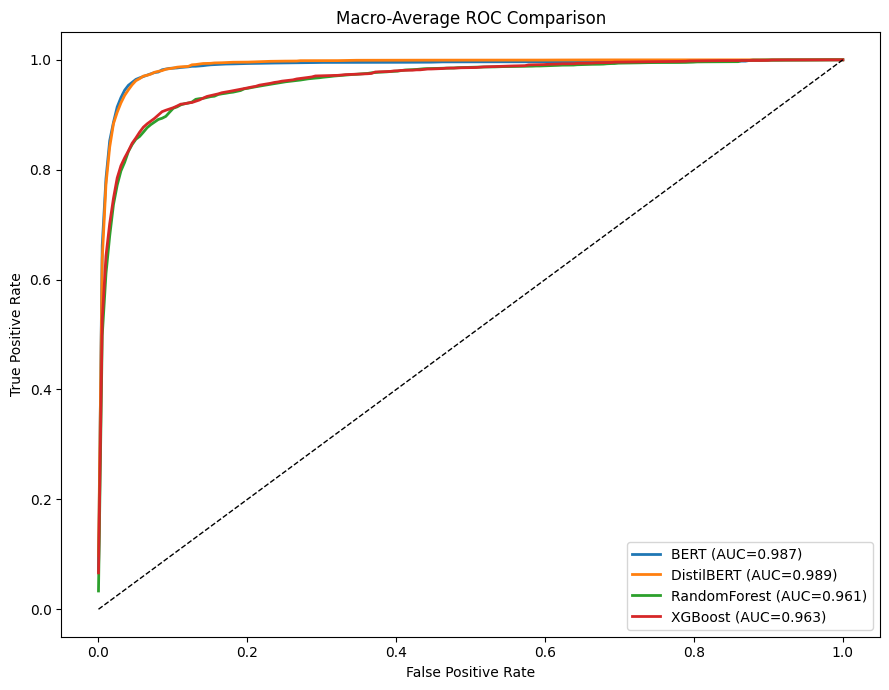

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

LABEL_COLS = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

MODELS = [
    "BERT",
    "DistilBERT",
    "RandomForest",
    "XGBoost"
]

line_colors = [
    '#1f77b4',
    '#ff7f0e',
    '#2ca02c',
    '#d62728'
]

plt.figure(figsize=(9,7))

plotted = False

for model_name, color in zip(MODELS, line_colors):

    probs = all_probs[model_name]
    labels = all_labels[model_name]

    mean_fpr = np.linspace(0,1,200)

    tprs = []

    for idx in range(len(LABEL_COLS)):

        y_true = labels[:, idx]
        y_prob = probs[:, idx]

        if len(np.unique(y_true)) < 2:
            continue

        if np.isnan(y_prob).any():
            continue

        fpr, tpr, _ = roc_curve(y_true, y_prob)

        tprs.append(
            np.interp(mean_fpr, fpr, tpr)
        )

    if len(tprs) == 0:
        continue

    mean_tpr = np.mean(tprs, axis=0)

    macro_auc = auc(
        mean_fpr,
        mean_tpr
    )

    plt.plot(
        mean_fpr,
        mean_tpr,
        color=color,
        lw=2,
        label=f'{model_name} (AUC={macro_auc:.3f})'
    )

    plotted = True

if plotted:

    plt.plot(
        [0,1],
        [0,1],
        'k--',
        lw=1
    )

    plt.xlabel(
        'False Positive Rate'
    )

    plt.ylabel(
        'True Positive Rate'
    )

    plt.title(
        'Macro-Average ROC Comparison'
    )

    plt.legend(
        loc='lower right'
    )

    plt.tight_layout()

    plt.savefig(
        'roc_all_models.png',
        dpi=150
    )

    plt.show()

else:
    print("No valid ROC curves found.")

plt.close()

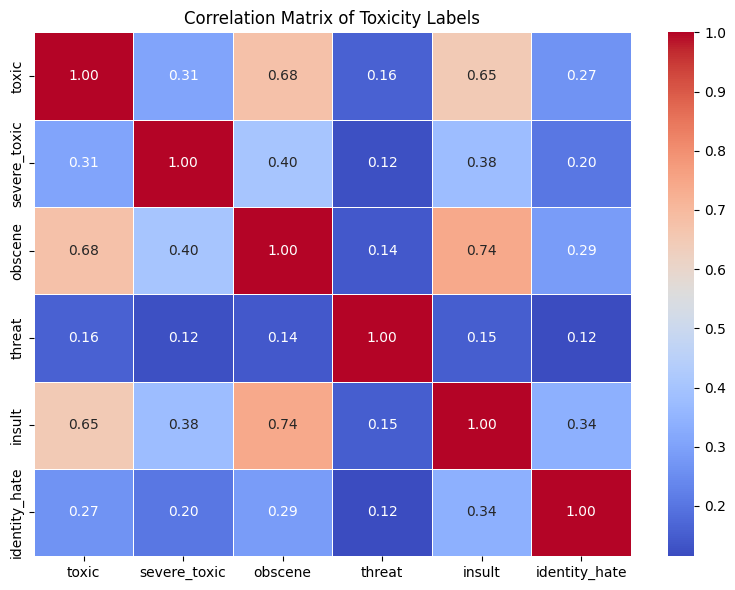

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

LABEL_COLS = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

corr_matrix = df[LABEL_COLS].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Toxicity Labels')
plt.tight_layout()

plt.savefig('correlation_matrix.png', dpi=150)

plt.show()


Top 20 Toxic Keywords

         Word  Frequency
0        fuck       7215
1        shit       3007
2      nigger       2653
3   wikipedia       2526
4         ass       2433
5        like       2419
6     fucking       2351
7        what       2305
8        hate       1948
9        suck       1879
10        die       1864
11      moron       1784
12        don       1760
13       just       1742
14        fat       1736
15        get       1704
16        who       1675
17        off       1592
18      about       1515
19       page       1507


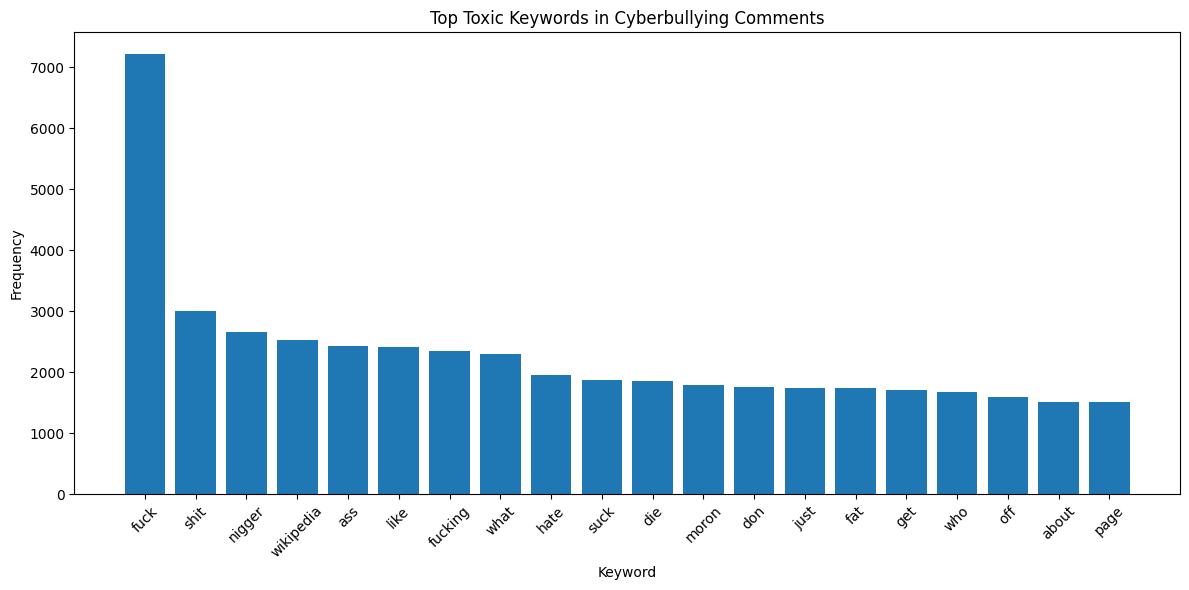

In [ ]:
from collections import Counter
import re
import pandas as pd
import matplotlib.pyplot as plt

df = dataset['train'].to_pandas()

toxic_comments = df[df['toxic'] == 1]['comment_text']

words = []

for text in toxic_comments:

    text = str(text).lower()

    words.extend(
        re.findall(r'\b[a-z]+\b', text)
    )

stop_words = {
    'the','a','an','and','or','to','of','is','are',
    'was','were','in','on','for','with','that','this',
    'it','be','as','at','by','from','you','your',
    'have','has','had','they','them','their',
    'his','her','she','he','will','would',
    'can','could','not','but','all','any'
}

words = [
    w for w in words
    if w not in stop_words and len(w) > 2
]

counter = Counter(words)

top_words = counter.most_common(20)

keyword_df = pd.DataFrame(
    top_words,
    columns=['Word', 'Frequency']
)

print("\nTop 20 Toxic Keywords\n")
print(keyword_df)

plt.figure(figsize=(12,6))

plt.bar(
    keyword_df['Word'],
    keyword_df['Frequency']
)

plt.xticks(rotation=45)

plt.xlabel("Keyword")
plt.ylabel("Frequency")

plt.title(
    "Top Toxic Keywords in Cyberbullying Comments"
)

plt.tight_layout()

plt.savefig(
    "toxic_keywords.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
def get_severity(probability):

    if probability < 0.30:
        return "Low"

    elif probability < 0.70:
        return "Medium"

    else:
        return "High"

In [ ]:
def moderation_action(severity):

    if severity == "Low":
        return "Allow"

    elif severity == "Medium":
        return "Warning"

    else:
        return "Flag for Review"

In [ ]:
import torch
import os
import glob
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

LABEL_COLS = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

THRESHOLD = 0.5


best_model_name = max(
    TRANSFORMER_MODELS.keys(),
    key=lambda m: test_results[m]['roc_auc']
)

best_checkpoint = TRANSFORMER_MODELS[best_model_name]

best_local_dir = (
    f'./toxic-multilabel-{best_model_name.lower()}'
)

print(
    f' Best model: {best_model_name} '
    f'(Test AUC = {test_results[best_model_name]["roc_auc"]:.4f})'
)


checkpoint_dirs = sorted(
    glob.glob(
        os.path.join(
            best_local_dir,
            'checkpoint-*'
        )
    ),
    key=os.path.getmtime
)

if checkpoint_dirs:

    best_ckpt_path = checkpoint_dirs[-1]

    print(
        f'   Found checkpoint: {best_ckpt_path}'
    )

else:

    best_ckpt_path = best_local_dir

    print(
        f'   No checkpoint found, using root: '
        f'{best_ckpt_path}'
    )


best_tokenizer = AutoTokenizer.from_pretrained(
    best_checkpoint
)

best_model = AutoModelForSequenceClassification.from_pretrained(
    best_ckpt_path,
    num_labels=len(LABEL_COLS),
    problem_type='multi_label_classification',
    ignore_mismatched_sizes=True
)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

best_model.to(device)
best_model.eval()

print(f'   Loaded on device: {device}')


def get_severity(probability):

    if probability < 0.30:
        return "Low"

    elif probability < 0.70:
        return "Medium"

    else:
        return "High"


def moderation_action(severity):

    if severity == "Low":
        return "Allow"

    elif severity == "Medium":
        return "Warning"

    else:
        return "Flag for Review"


def predict(texts):

    enc = best_tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

    enc = {
        k: v.to(device)
        for k, v in enc.items()
    }

    with torch.no_grad():

        logits = best_model(**enc).logits

    probs = torch.sigmoid(
        logits
    ).cpu().numpy()

    preds = (
        probs >= THRESHOLD
    ).astype(int)

    return probs, preds


test_texts = [

    "You are absolutely wonderful, keep up the great work!",

    "I will find you and make you regret this, you idiot.",

    "This is a neutral comment about the weather today."
]

probs, preds = predict(test_texts)


for i, text in enumerate(test_texts):

    print(f'\nText: "{text}"')

    max_prob = probs[i].max()

    severity = get_severity(
        max_prob
    )

    action = moderation_action(
        severity
    )

    print(
        f'   Severity Level: {severity}'
    )

    print(
        f'   Recommended Action: {action}'
    )

    print('\n   Predictions:')

    for j, label in enumerate(LABEL_COLS):

        flag = (
            '🔴'
            if preds[i][j] == 1
            else '🟢'
        )

        print(
            f'     {flag} '
            f'{label:<15} '
            f'prob={probs[i][j]:.3f}'
        )

🏆 Best model: DistilBERT (Test AUC = 0.9898)
   Found checkpoint: ./toxic-multilabel-distilbert/checkpoint-10473


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

   Loaded on device: cuda

Text: "You are absolutely wonderful, keep up the great work!"
   Severity Level: Low
   Recommended Action: Allow

   Predictions:
     🟢 toxic           prob=0.000
     🟢 severe_toxic    prob=0.000
     🟢 obscene         prob=0.000
     🟢 threat          prob=0.000
     🟢 insult          prob=0.000
     🟢 identity_hate   prob=0.000

Text: "I will find you and make you regret this, you idiot."
   Severity Level: High
   Recommended Action: Flag for Review

   Predictions:
     🔴 toxic           prob=0.997
     🟢 severe_toxic    prob=0.101
     🔴 obscene         prob=0.726
     🟢 threat          prob=0.085
     🔴 insult          prob=0.943
     🟢 identity_hate   prob=0.008

Text: "This is a neutral comment about the weather today."
   Severity Level: Low
   Recommended Action: Allow

   Predictions:
     🟢 toxic           prob=0.000
     🟢 severe_toxic    prob=0.000
     🟢 obscene         prob=0.000
     🟢 threat          prob=0.000
     🟢 insult          prob

In [ ]:
from google.colab import drive
import os

try:
    drive.flush_and_unmount()
except:
    pass

drive.mount('/content/drive')

if os.path.exists('/content/drive/MyDrive'):
    print(" Google Drive mounted successfully")
else:
    print(" Google Drive mount failed")

Mounted at /content/drive
 Google Drive mounted successfully


In [ ]:
import shutil

best_model_name = max(
    TRANSFORMER_MODELS.keys(),
    key=lambda m: test_results[m]['roc_auc']
)

local_path = (
    f'./toxic-multilabel-{best_model_name.lower()}'
)

save_path = (
    f'/content/drive/MyDrive/'
    f'toxic-multilabel-best-{best_model_name.lower()}'
)

print(
    f' Best model: {best_model_name} '
    f'(Test AUC = '
    f'{test_results[best_model_name]["roc_auc"]:.4f})'
)

shutil.copytree(
    local_path,
    save_path,
    dirs_exist_ok=True
)

print(f' Saved to: {save_path}')

 Best model: DistilBERT (Test AUC = 0.9898)
 Saved to: /content/drive/MyDrive/toxic-multilabel-best-distilbert


In [ ]:
import glob
import shutil
import os

save_dir = '/content/drive/MyDrive/toxic_paper_figures'
os.makedirs(save_dir, exist_ok=True)

png_files = glob.glob('./*.png')
for f in png_files:
    shutil.copy(f, save_dir)
    print(f' Copied: {f}')

print(f'\n All figures saved to: {save_dir}')

 Copied: ./confusion_distilbert.png
 Copied: ./confusion_xgboost.png
 Copied: ./best_model_performance.png
 Copied: ./confusion_randomforest.png
 Copied: ./roc_xgboost.png
 Copied: ./roc_distilbert.png
 Copied: ./confusion_bert.png
 Copied: ./roc_bert.png
 Copied: ./correlation_matrix.png
 Copied: ./roc_randomforest.png
 Copied: ./model_comparison.png
 Copied: ./roc_all_models.png
 Copied: ./toxic_keywords.png

 All figures saved to: /content/drive/MyDrive/toxic_paper_figures
